# Smart Distribution Systems (B-KUL-H00P3A)


This exercise session will familiarize you with basic concepts from machine learning and show you how these concepts can be used within power systems for forecasting.

You will learn to:
* set up a machine learning environment, using state-of-the-art tools, such as keras, tensorflow and theano in Python;
* implement and train a two-layer neural network using Keras;
* use this neural network to make prediction about the wholesale electricity price.


In [1]:
import pandas as pd
import numpy as np
#%matplotlib ipympl
import matplotlib.pyplot as plt
import time
import pickle
import datetime
import datetime as dt
import io
from sklearn.model_selection import train_test_split, cross_val_predict, KFold

The next code snippet allow us to upload our data to Google Colab. The execution of the next two lines generate a widget window that you can use to browse your computer for the csv files used in this exercise session: 'Full_Dataset.csv' and 'belpex_2011.csv'. Upload these files to the Google Colab environment.

In [ ]:
#from google.colab import files
#uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

For more information on de pandas data frame see: http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.html

In [2]:
start_date = dt.datetime(2021,1,1)
end_date = dt.datetime(2026,2,25)

First we'll import the csv with the solar, wind, and price data into pandas. Use the pandas documentation to figure out what each of lines do in the next piece of code.

In [5]:
#df_all = pd.read_csv(io.BytesIO(uploaded['Full_Dataset.csv']), header=0)
#df_all.head()
import pandas as pd
import io

# Direct local path instead of using the 'uploaded' dictionary
df_all = pd.read_csv('Full_Dataset.csv', header=0)

# If the data looks like one giant column, use the semicolon delimiter mentioned in your notebook:
# df_all = pd.read_csv('Full_Dataset.csv', delimiter=';', header=0)

df_all.head()

,Date,Price_BE,Load_FR,Gen_FR,Price_CH,Wind_BE,Solar_BE,Load_BE
0,01/01/2021 00:00,48.19,64600.0,62414.0,45.94,484.1150,0.0,8571.4375
1,01/01/2021 01:00,44.68,63700.0,60611.5,44.53,674.8450,0.0,8160.9775
2,01/01/2021 02:00,42.92,60600.0,58978.0,41.01,419.5400,0.0,7827.1225
3,01/01/2021 03:00,40.39,58150.0,58519.5,39.23,406.6575,0.0,7628.6800
4,01/01/2021 04:00,40.20,57450.0,57899.5,38.43,528.6450,0.0,7594.3100


If you see a single giant column or the data looks broken, try changing the delimiter to **','** or **';'** in the **read_csv** call in the cell below **(otherwise, you can skip it without running it)**, then check again using **df_all.head()** to see if everything looks normal.

In [ ]:
df_all = pd.read_csv(io.BytesIO(uploaded['Full_Dataset.csv']), delimiter=';', header=0)
df_all.head()

The below cell rename the first column to **'time'**, convert it to datetime format, and set it as the index for time-based analysis.

In [6]:
df_all.rename(columns={df_all.columns[0]: 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

In [7]:
df_all.head()

,Price_BE,Load_FR,Gen_FR,Price_CH,Wind_BE,Solar_BE,Load_BE
time,,,,,,,
2021-01-01 00:00:00,48.19,64600.0,62414.0,45.94,484.1150,0.0,8571.4375
2021-01-01 01:00:00,44.68,63700.0,60611.5,44.53,674.8450,0.0,8160.9775
2021-01-01 02:00:00,42.92,60600.0,58978.0,41.01,419.5400,0.0,7827.1225
2021-01-01 03:00:00,40.39,58150.0,58519.5,39.23,406.6575,0.0,7628.6800
2021-01-01 04:00:00,40.20,57450.0,57899.5,38.43,528.6450,0.0,7594.3100


For now, we're interested in the Solar Generation Forecast BE(Solar_BE).

In [8]:
df_solar = df_all.Solar_BE
df_solar.head()

time
2021-01-01 00:00:00    0.0
2021-01-01 01:00:00    0.0
2021-01-01 02:00:00    0.0
2021-01-01 03:00:00    0.0
2021-01-01 04:00:00    0.0
Name: Solar_BE, dtype: float64

We're also interested in the Wind Generation Forecast BE(Wind_BE)

In [9]:
df_wind = df_all.Wind_BE
df_wind.head()

time
2021-01-01 00:00:00    484.1150
2021-01-01 01:00:00    674.8450
2021-01-01 02:00:00    419.5400
2021-01-01 03:00:00    406.6575
2021-01-01 04:00:00    528.6450
Name: Wind_BE, dtype: float64

We're also interested in the Day-Ahead Price BE(Price_BE)

In [10]:
df_belpex = df_all.Price_BE
df_belpex.head()

time
2021-01-01 00:00:00    48.19
2021-01-01 01:00:00    44.68
2021-01-01 02:00:00    42.92
2021-01-01 03:00:00    40.39
2021-01-01 04:00:00    40.20
Name: Price_BE, dtype: float64

Unfortunately, in real-life datasets, sometimes, certain data is missing. We can see this by trying to assign the price to a variable named 'p' and catching the error if no value is available.

In [11]:
dates = pd.date_range(start=start_date, end=end_date, freq='1h')
for d in dates:
    try:
        p = df_belpex.loc[d]
    except KeyError:
        print(d)

2021-01-27 13:00:00
2021-01-27 14:00:00
2021-01-27 15:00:00
2021-03-28 02:00:00
2022-03-27 02:00:00
2022-04-18 11:00:00
2022-04-18 12:00:00
2022-04-18 13:00:00
2023-03-26 02:00:00
2024-02-03 14:00:00
2024-02-03 15:00:00
2024-02-03 16:00:00
2024-02-03 17:00:00
2024-02-03 18:00:00
2024-03-31 02:00:00
2024-09-20 16:00:00
2024-09-20 17:00:00
2024-09-20 18:00:00
2024-09-20 19:00:00
2024-09-20 20:00:00
2024-09-20 21:00:00
2024-09-20 22:00:00
2024-09-20 23:00:00
2025-03-30 02:00:00
2025-06-19 19:00:00
2025-06-19 20:00:00
2025-06-19 21:00:00
2025-06-19 22:00:00


We will have to take assumptions of these values. In this case it makes sense to either assume they are the same as the previous hour or the next hour. Or, to take the average of both. In this case we will just assume the price is the same as the previous hour.

In [12]:
dates = pd.date_range(start=start_date, end=end_date, freq='1h')
for d in dates:
    try:
        p1 = df_solar.loc[d]
        p2 = df_wind.loc[d]
        p3 = df_belpex.loc[d]
    except KeyError:
        df_solar.loc[d] = df_solar.loc[d-dt.timedelta(hours=1)]
        df_wind.loc[d] = df_wind.loc[d-dt.timedelta(hours=1)]
        df_belpex.loc[d] = df_belpex.loc[d-dt.timedelta(hours=1)]
df_solar = df_solar.sort_index()
df_solar = df_solar[start_date:end_date]

df_wind = df_wind.sort_index()
df_wind = df_wind[start_date:end_date]

df_belpex = df_belpex.sort_index()
df_belpex = df_belpex[start_date:end_date]

If our dataset has NaN (Not a Number) values, we don't want them. Instead, we'll fill in these missing spots with the nearest valid data before them. You can use the code in the next cell to do this. <br>
Check for nan's in the dataset in the next cell!

In [14]:
# Replace the deprecated 'method' argument with the new .ffill() method
df_solar = df_solar.ffill()
df_wind = df_wind.ffill()
df_belpex = df_belpex.ffill()

Additionally, it's important to note that datasets may sometimes vary in their time granularity. Although this particular issue does not arise in our current analysis, should you encounter differing time resolutions across datasets, there are several strategies to address this challenge effectively. For guidance on harmonizing time granularities, It is recommended exploring the resampling techniques outlined in the pandas documentation, which can be found here:: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.resample.html

In [15]:
d = {'belpex': df_belpex.values, 'solar': df_solar.values, 'wind': df_wind.values}
data = pd.DataFrame(index=df_belpex.index, data=d)
data.head()

,belpex,solar,wind
time,,,
2021-01-01 00:00:00,48.19,0.0,484.1150
2021-01-01 01:00:00,44.68,0.0,674.8450
2021-01-01 02:00:00,42.92,0.0,419.5400
2021-01-01 03:00:00,40.39,0.0,406.6575
2021-01-01 04:00:00,40.20,0.0,528.6450


Usefull commands
* data.head(10) prints the first 10 samples
* data.tail(10) prints the last 10 samples
* data.$wind$ prints the collumn with label $wind$
* data.wind.plot plots the wind timeseries

# 1. Visualize the data

In [16]:
print(data.head(10))
print(data.tail(10))

                     belpex     solar      wind
time                                           
2021-01-01 00:00:00   48.19    0.0000  484.1150
2021-01-01 01:00:00   44.68    0.0000  674.8450
2021-01-01 02:00:00   42.92    0.0000  419.5400
2021-01-01 03:00:00   40.39    0.0000  406.6575
2021-01-01 04:00:00   40.20    0.0000  528.6450
2021-01-01 05:00:00   39.63    0.0000  317.4625
2021-01-01 06:00:00   40.09    0.0000  349.0750
2021-01-01 07:00:00   41.27    1.8025  293.0675
2021-01-01 08:00:00   44.88  102.3300  216.7525
2021-01-01 09:00:00   45.00  313.7000  322.9850
                       belpex      solar     wind
time                                             
2026-02-24 15:00:00   88.6225  699.15450  346.775
2026-02-24 16:00:00  120.4300  207.08700  280.475
2026-02-24 17:00:00  122.0025    4.25875  311.250
2026-02-24 18:00:00  113.9350    0.00000  421.075
2026-02-24 19:00:00  107.7350    0.00000  505.100
2026-02-24 20:00:00   90.2975    0.00000  623.600
2026-02-24 21:00:00   85

Create a plot of the different collums using matplotlib.

Plotting with matplotlib.pyplot is very similar to plotting in matlab. Some key commands:
* <b>plt.figure()</b>: creates a new, blank figure. This changes the current graph and axis to the newly created ones. All commands applied hereafter will be applied to the new, current figure.
* <b>plt.show()</b>: show the figure. If you don't execute this command, no figure will show.
* For more commands, see http://matplotlib.org/users/pyplot_tutorial.html

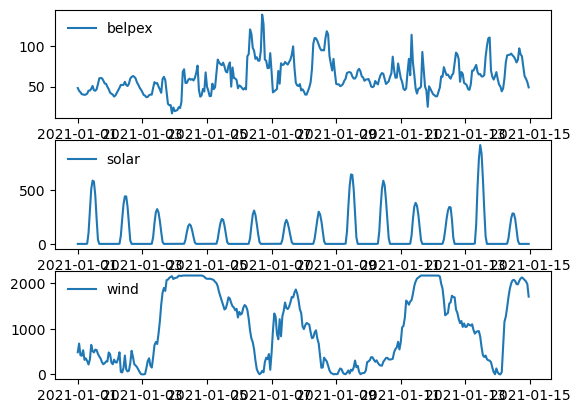

In [17]:
start = datetime.datetime(2021, 1, 1, 0, 0)
end = datetime.datetime(2021, 1, 14, 23, 45)

plt.figure()
plt.subplot(311)
plt.plot(data.belpex[start:end], label='belpex')
plt.legend(frameon=False)
plt.subplot(312)
plt.plot(data.solar[start:end], label='solar')
plt.legend(frameon=False)
plt.subplot(313)
plt.plot(data.wind[start:end], label='wind')
plt.legend(frameon=False)
plt.show()

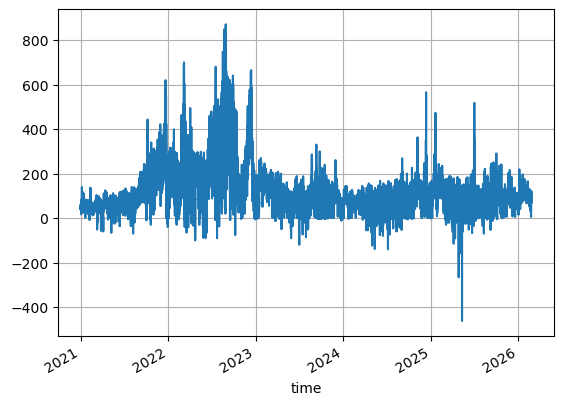

In [18]:
plt.figure()
data.belpex.plot(grid=True)
plt.show()

# 2. Clean the data by removing outliers

Outliers are mostly difficult, if not impossible, to predict. Therefore, we like to remove them. Moreover, sometimes these outliers are not even correct.

As an example you can check out the belpex price of the year 2011.

<Axes: >

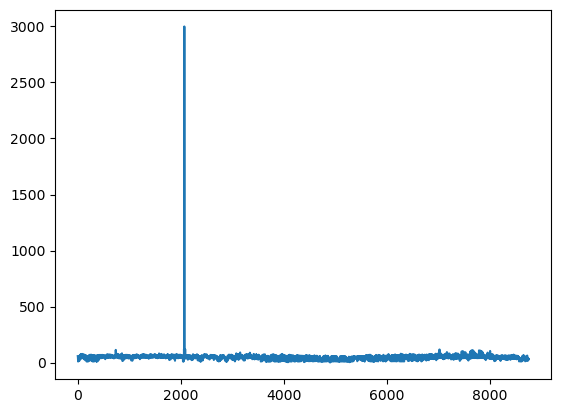

In [22]:
# Direct local path instead of using the Colab 'uploaded' dictionary
df = pd.read_csv('belpex_2011.csv', header=0)
df.price.plot()

Read why this happened in this study of the CREG: http://www.creg.be/nl/publicaties/study-on-price-spike-on-belpex-dam-28-march-2011 .

Clue: Use a generic method from statistics that is independent of the timeseries

In [23]:
mean = data.belpex.mean()
std = data.belpex.std()
n_std = 5
data['belpex'][(data.belpex >= mean + n_std*std)] = mean + n_std*std
data['belpex'][(data.belpex <= mean - n_std*std)] = mean + n_std*std

C:\Users\sarah\AppData\Local\Temp\ipykernel_23488\4235144742.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  data['belpex'][(data.belpex >= mean + n_std*std)] = mean + n_std*std
C:\Users\sarah\AppData\Local\Temp\ipykernel_23488\4235144742.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are sett

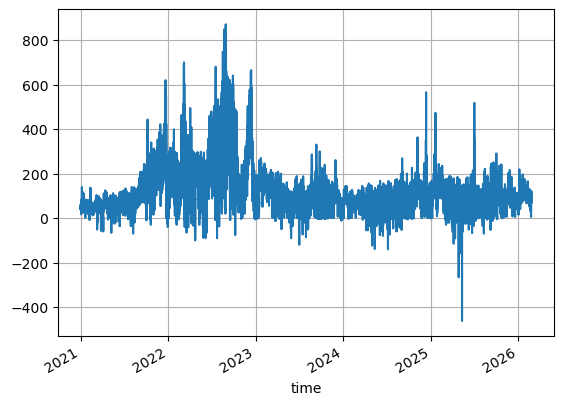

In [24]:
plt.figure()
data.belpex.plot(grid=True)
plt.show()

# 3. Create boxplot

It is always useful to get more insight in the data you are using.

Create a boxplot grouped by
* days in the week
* months
* hours
* years

http://pandas.pydata.org/pandas-docs/version/0.13.1/visualization.html

A pandas dataframe has a table like structure. The very first column in the table contains the indices, uniquely identifying each row in the table. These indices can be a set of integers, or like in this case, a set of timestamps, points in time when the specified data was realised.

'data.index' will return all timestamps of the dataset as an array. These timestamps have certain attributes available. For a reference, see:
http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DatetimeIndex.html

Below, attributes of the datetime indices are stored in a new column of the table. This allows us to create box plots grouped by these attributes, such as day of the week, hour, etc.

<Axes: title={'center': 'belpex'}, xlabel='month_days'>

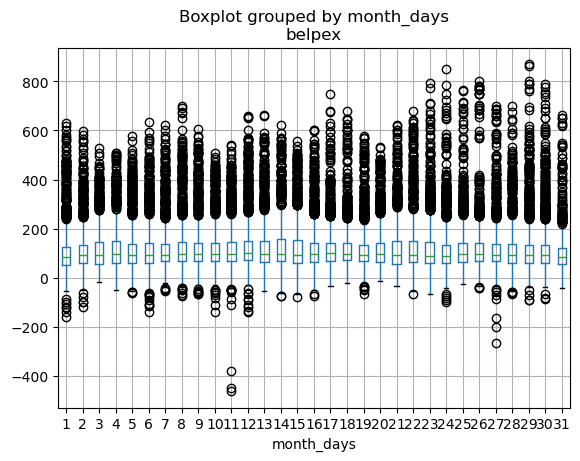

In [25]:
data['week_days']=data.index.weekday
data['month_days']=data.index.day
data['hours']=data.index.hour
data['months']=data.index.month

data.boxplot(column='belpex', by='month_days')

<Axes: title={'center': 'belpex'}, xlabel='week_days'>

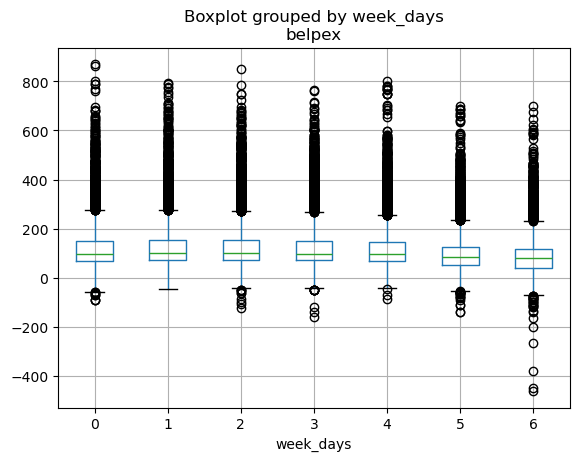

In [26]:
data.boxplot(column='belpex', by='week_days')

<Axes: title={'center': 'belpex'}, xlabel='hours'>

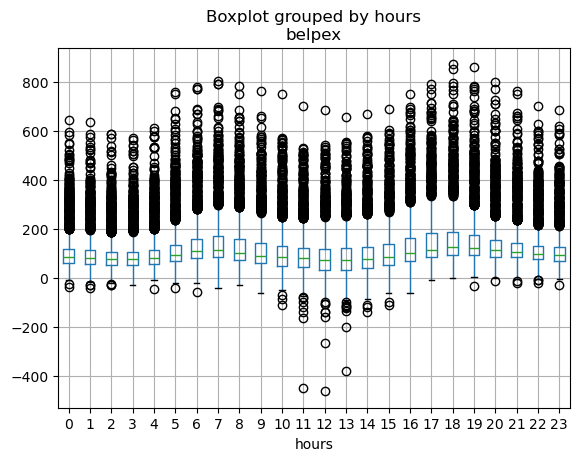

In [27]:
data.boxplot(column='belpex', by='hours')

<Axes: title={'center': 'belpex'}, xlabel='months'>

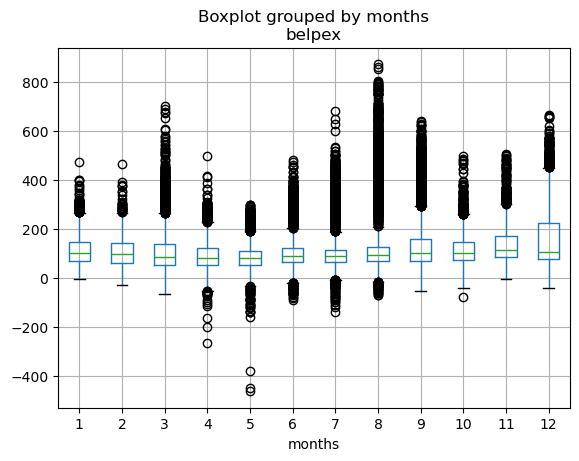

In [28]:
data.boxplot(column='belpex', by='months')

Finally, <b>give it a try yourself</b>. Make a boxplot grouped by the year.

<Axes: title={'center': 'belpex'}, xlabel='years'>

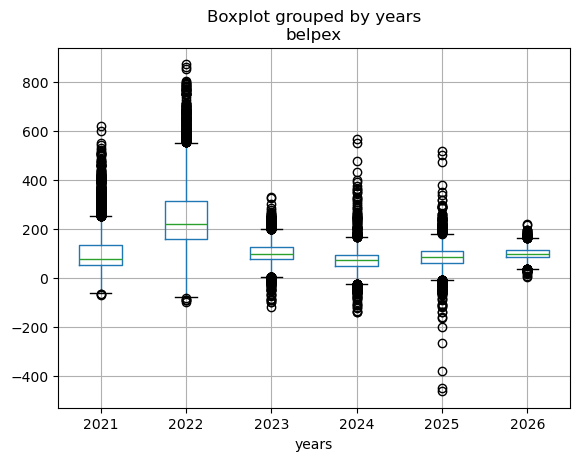

In [30]:
# 1. Extract the year from the index and store it in a new column
data['years'] = data.index.year

# 2. Generate the boxplot grouped by this new 'years' column
data.boxplot(column='belpex', by='years')

# 4. Check for randomness in the time series using an autocorrelation plot

This is done by computing autocorrelations for data values at varying time lags. If time series is random, such autocorrelations should be near zero for any and all time-lag separations. If time series is non-random then one or more of the autocorrelations will be significantly non-zero.

The autocorrelation is the correlation of a timeseries with a delayed copy of itself and is given by:
\begin{equation}
R(\tau) = \frac{E[(X_{t}-\mu)(X_{t+\tau}-\mu)]}{\sigma^2}
\end{equation}
where $X_t$ is the time series and $\tau$ is the time-lag.

How to make an autocorrelation plot using pandas in python:
http://pandas.pydata.org/pandas-docs/stable/visualization.html#visualization-autocorrelation

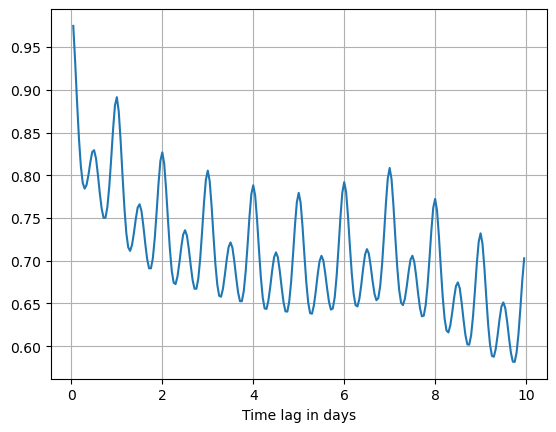

In [31]:
# Autocorrelation
lags = np.arange(1, 24*1*10)
acors = []
for lag in lags:
    acors.append(data.belpex.autocorr(lag))
plt.figure()
plt.plot(lags/1/24.0, acors)
plt.xlabel('Time lag in days')
plt.grid(True)

# 5. Create a scatter matrix

<b>Why use a scatter plot matrix?</b>

You have three types of data:
* electricity price $p$
* solar generation $s$
* wind generation $w$

For certain moments in time, we have three data points. This means we could think of our dataset as points in a four-dimensional space:
$$\begin{Bmatrix}t\\p\\s\\w\end{Bmatrix}$$

Unless you can think of your dataset in four dimensions, let's make it a bit easier. First, we strip away the time dimension. This leaves us with a more dense three-dimensional space containing all our samples. Still, we don't like to think in three dimensions. So let's just try all possible pairs of the remaining dimensions.

We visualize each pair with a scatter plot. A scatter plot is simply a graph with dots, which are not connected. Hence, we get a matrix of scatter plots, a scatter matrix.

We do all of this to explore our dataset, and find relationships in our data. For example, if the 'price vs solar generation' scatter plot shows dots centered around a straight line, then we can conclude that there is a linear relationship between price and solar generation. This is something that we could exploit later on, when we make our model.

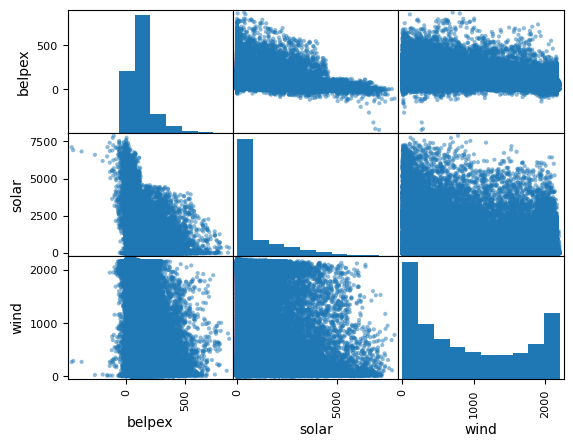

In [32]:
import pandas as pd
a = pd.plotting.scatter_matrix(data[['belpex', 'solar', 'wind']])

If the diagonal is not what you would expect, then you are right. For more information, see

http://stackoverflow.com/questions/26360759/understanding-the-diagonal-in-pandas-scatter-matrix-plot

# 6. Linear regression

Metric to define the quality of the foreceast

In [33]:
def get_accuracy(x, y):
    return np.mean(np.abs(x - y))/np.mean(x)

In this section, we will use the scikit learn toolbox. For more information, see
* [API reference](http://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection)
* [Tutorials](http://scikit-learn.org/stable/tutorial/index.html)

In [34]:
from sklearn.linear_model import LinearRegression, Ridge
model = LinearRegression()
lags = [24*1] + list(range(24*1*7, 24*1*35, 24*1))
features = ['wind', 'solar']
print(lags)
len(lags)

[24, 168, 192, 216, 240, 264, 288, 312, 336, 360, 384, 408, 432, 456, 480, 504, 528, 552, 576, 600, 624, 648, 672, 696, 720, 744, 768, 792, 816]


29

In [35]:
index = data.index
for lag in lags:
    data['belpex_lag_{}'.format(lag)] = data.belpex.shift(lag)
    features.append('belpex_lag_{}'.format(lag))
data['day_in_year'] = data.index.dayofyear
data = data.loc[index, :]
data = data.dropna()

X = data[features]
y = data.belpex

cv = KFold(n_splits=10, shuffle=False)
data['belpex_pred'] = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)

print(get_accuracy(data.belpex, data.belpex_pred))

0.2159692428046


In [36]:
print(features)

['wind', 'solar', 'belpex_lag_24', 'belpex_lag_168', 'belpex_lag_192', 'belpex_lag_216', 'belpex_lag_240', 'belpex_lag_264', 'belpex_lag_288', 'belpex_lag_312', 'belpex_lag_336', 'belpex_lag_360', 'belpex_lag_384', 'belpex_lag_408', 'belpex_lag_432', 'belpex_lag_456', 'belpex_lag_480', 'belpex_lag_504', 'belpex_lag_528', 'belpex_lag_552', 'belpex_lag_576', 'belpex_lag_600', 'belpex_lag_624', 'belpex_lag_648', 'belpex_lag_672', 'belpex_lag_696', 'belpex_lag_720', 'belpex_lag_744', 'belpex_lag_768', 'belpex_lag_792', 'belpex_lag_816']


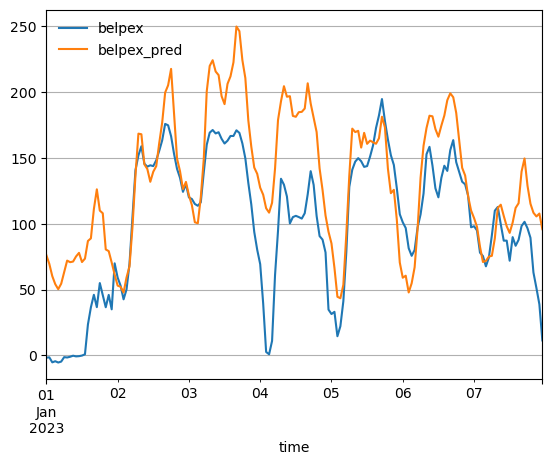

In [37]:
start = datetime.datetime(2023, 1, 1, 0, 0)
end = datetime.datetime(2023, 1, 7, 23, 45)

plt.figure()
data.belpex[start:end].plot(grid=True)
data.belpex_pred[start:end].plot(grid=True)
plt.legend(frameon=False,loc=2)
plt.show()

# 7. Neural network (a naive implementation)

In [38]:
import os

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop, SGD

Create input and output training data. <br>
We will just predict the next day, based on the previous day.

In [40]:
n_hours = 24
start = datetime.datetime(2023, 1, 1, 0, 0)
end = datetime.datetime(2023, 12, 29, 23, 45)
X = data['belpex'][start:end].resample('1h').mean().values.reshape(-1, n_hours)


start = datetime.datetime(2023, 1, 2, 0, 0)
end = datetime.datetime(2023, 12, 30, 23, 45)
Y = data['belpex'][start:end].resample('1h').mean().values.reshape(-1, n_hours)

In [41]:
print(data['belpex'][start:end].resample('1h').mean().shape)

(8712,)


In [42]:
print('input_features ' + str(X.shape))
print('target dimensions ' + str(Y.shape))

input_features (363, 24)
target dimensions (363, 24)


Create neural network with one hidden layer

In [43]:
neurons = [24, 24 ]
activation_functions = ['relu', 'linear']

model = Sequential()
model.add(Dense(neurons[0], input_dim=X.shape[1], activation=activation_functions[0]))
model.add(Dense(neurons[1], activation=activation_functions[1]))

rprop = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-6)
model.compile(loss='mean_squared_error', optimizer=rprop)

c:\Users\sarah\anaconda3\envs\smart_grid_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
output_training = model.fit(X, Y, epochs=500, batch_size=32, verbose=0)
mse = output_training.history['loss'][-1]
print('- mse is %.4f' % mse + ' @ ' + str(len(output_training.history['loss'])))

- mse is 517.5912 @ 500


In [45]:
predict_nn = model.predict(X)
print(get_accuracy(Y.flatten(), predict_nn.flatten()))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
0.17053641152581123


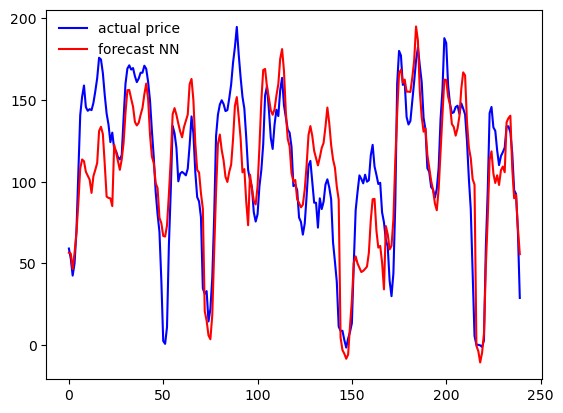

In [46]:
# Plots
plt.figure()
plt.plot(Y[:10,:].flatten(), color='blue', label='actual price')
plt.plot(predict_nn[:10,:].flatten(), color='red', label='forecast NN')
plt.legend(frameon=False)
plt.show()

# 8. Improve the naive implementation in Step 7


* Create test and validation set
    * https://en.wikipedia.org/wiki/Test_set
    * http://stats.stackexchange.com/questions/19048/what-is-the-difference-between-test-set-and-validation-set
* Add additional features
    * same day of the previous week (see autocorrelation plot)
    * use a wind and solar forecast as an additional feature (assume you can make perfect forecasts)
    * Use EliaTotalLoad from datafetcher
    * Are there other features that have an influence on the price and thus may affect prediction performance
* Tune the structure of the neural network (use grid search)
    * number of layers
        * http://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw
    * different activation functions
        * https://en.wikipedia.org/wiki/Activation_function

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Handle Duplicates in the original dataframe
# This averages any duplicate timestamps (like the 2:00 AM hour in October)
df_all = df_all[~df_all.index.duplicated(keep='first')] # Option A: Keep first
# OR 
# df_all = df_all.groupby(level=0).mean() # Option B: Average duplicates (Recommended)

# 2. Re-create the 'data' DataFrame including Load
# It is safer to resample everything together to keep it aligned
data = df_all[['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']].resample('1h').mean().ffill()

# Rename columns to match your notebook's naming convention
data.columns = ['belpex', 'solar', 'wind', 'load']

# 3. Extract values
price = data.belpex.values
solar = data.solar.values
wind = data.wind.values
load = data.load.values

n_hours = 24
X_list, Y_list = [], []
days = len(data) // n_hours

# 4. Build feature sets (Lag 1 day, Lag 7 days, and current day "forecasts")
for d in range(7, days):
    # Target: 24 hours of price for the current day
    y_day = price[d*24 : (d+1)*24]
    
    # Inputs (Features)
    price_lag1 = price[(d-1)*24 : d*24]    # Yesterday's Prices
    price_lag7 = price[(d-7)*24 : (d-6)*24] # Prices from same day last week
    solar_curr = solar[d*24 : (d+1)*24]    # Today's Solar (Forecast)
    wind_curr = wind[d*24 : (d+1)*24]      # Today's Wind (Forecast)
    load_curr = load[d*24 : (d+1)*24]      # Today's Load (Forecast)
    
    # Merge all 120 features (24*5) into one row
    X_list.append(np.concatenate([price_lag1, price_lag7, solar_curr, wind_curr, load_curr]))
    Y_list.append(y_day)

X, Y = np.array(X_list), np.array(Y_list)

print(f"Feature set created successfully!")
print(f"X shape: {X.shape} (Days, 120 Features)")
print(f"Y shape: {Y.shape} (Days, 24 Targets)")

Feature set created successfully!
X shape: (1874, 120) (Days, 120 Features)
Y shape: (1874, 24) (Days, 24 Targets)


Advice: read the documentation on https://keras.io/ for help

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Initialize scalers
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Fit and transform the data
# X contains 120 features (lagged prices, solar, wind, load)
# Y contains 24 targets (hourly prices for the next day)
X_scaled = scaler_x.fit_transform(X)
Y_scaled = scaler_y.fit_transform(Y)

# First split: Separate the final 15% as a Test Set (unseen data)
X_train_val, X_test, Y_train_val, Y_test = train_test_split(
    X_scaled, Y_scaled, test_size=0.15, shuffle=False
)

# Second split: Split the remaining 85% into Train (70% total) and Validation (15% total)
# 0.176 is roughly 15/85
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_val, Y_train_val, test_size=0.176, shuffle=False
)

print(f"Train shapes: {X_train.shape}, {Y_train.shape}")
print(f"Validation shapes: {X_val.shape}, {Y_val.shape}")
print(f"Test shapes: {X_test.shape}, {Y_test.shape}")

Train shapes: (1311, 120), (1311, 24)
Validation shapes: (281, 120), (281, 24)
Test shapes: (282, 120), (282, 24)


Epoch 1/100


c:\Users\sarah\anaconda3\envs\smart_grid_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5232 - val_loss: 0.1635
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2461 - val_loss: 0.1179
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1766 - val_loss: 0.1075
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1554 - val_loss: 0.1038
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1393 - val_loss: 0.1037
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1292 - val_loss: 0.0940
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1185 - val_loss: 0.0996
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1167 - val_loss: 0.0946
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1147 - val_loss: 0.1079
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1216 - val_loss: 0.0905
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1037 - val_loss: 0.1006
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1028 - val_lo

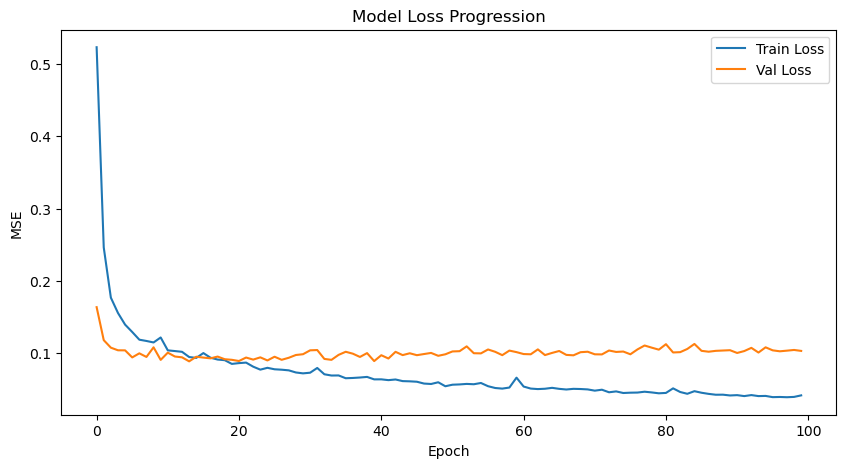

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Define the architecture
model = Sequential([
    Dense(96, input_dim=X_train.shape[1], activation='tanh'),
    Dense(96, activation='tanh'),
    Dense(24, activation='linear') # Output layer for 24 hourly prices
])

# Compile with Adam optimizer
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))

# Train the model
# We use the validation_data parameter to monitor for overfitting
history = model.fit(
    X_train, Y_train, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val, Y_val), 
    verbose=1
)

# Plot training & validation loss to check for convergence
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Final Test Error Ratio: 0.2331


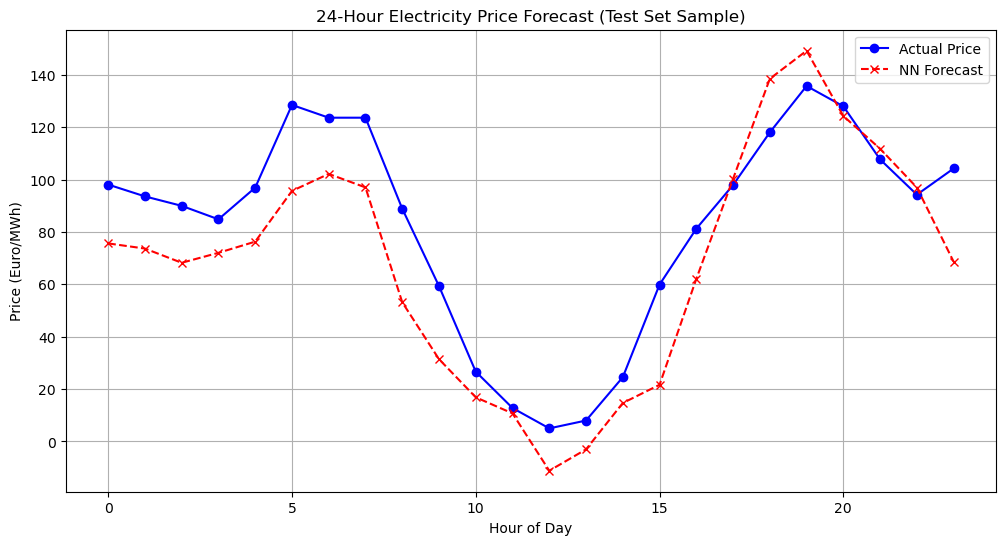

In [52]:
# Predict on the test set
predictions_scaled = model.predict(X_test)

# Invert scaling to get actual price values
predictions = scaler_y.inverse_transform(predictions_scaled)
actuals = scaler_y.inverse_transform(Y_test)

# Use the notebook's accuracy metric: mean(|error|) / mean(actual)
def get_accuracy(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred)) / np.mean(y_true)

test_acc = get_accuracy(actuals, predictions)
print(f"\nFinal Test Error Ratio: {test_acc:.4f}")

# Visualize a specific day from the test set (e.g., the first day)
plt.figure(figsize=(12, 6))
plt.plot(actuals[0], label='Actual Price', color='blue', marker='o')
plt.plot(predictions[0], label='NN Forecast', color='red', linestyle='--', marker='x')
plt.title('24-Hour Electricity Price Forecast (Test Set Sample)')
plt.xlabel('Hour of Day')
plt.ylabel('Price (Euro/MWh)')
plt.legend()
plt.grid(True)
plt.show()

In [53]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Define the grid of architectures to test
layer_options = [1, 2, 3]          # Number of hidden layers
node_options = [32, 64, 128]       # Neurons per hidden layer
results_list = []

print("Starting architecture comparison...")

# 2. Iterate through combinations
for num_layers in layer_options:
    for num_nodes in node_options:
        print(f"Training Model: Layers={num_layers}, Nodes={num_nodes}...", end=" ")
        
        # Build the specific model
        model = Sequential()
        # First layer (needs input_dim)
        model.add(Dense(num_nodes, input_dim=X_train.shape[1], activation='tanh'))
        
        # Add additional hidden layers
        for _ in range(num_layers - 1):
            model.add(Dense(num_nodes, activation='tanh'))
            
        # Output layer (24 hours)
        model.add(Dense(24, activation='linear'))
        
        model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
        
        # Train for a moderate amount of epochs for comparison
        history = model.fit(
            X_train, Y_train, 
            epochs=50, 
            batch_size=32, 
            validation_data=(X_val, Y_val), 
            verbose=0
        )
        
        # 3. Evaluate on Validation Set and Test Set
        val_mse = model.evaluate(X_val, Y_val, verbose=0)
        test_mse = model.evaluate(X_test, Y_test, verbose=0)
        
        # Save results to the list
        results_list.append({
            'Layers': num_layers,
            'Nodes_per_Layer': num_nodes,
            'Val_MSE': round(val_mse, 5),
            'Test_MSE': round(test_mse, 5)
        })
        print(f"Done. Val MSE: {val_mse:.5f}")

# 4. Create and display the comparison table
comparison_df = pd.DataFrame(results_list)

# Sort by Validation MSE to see the best performing model at the top
comparison_df = comparison_df.sort_values(by='Val_MSE', ascending=True)

print("\n--- Model Comparison Table ---")
print(comparison_df.to_string(index=False))

# Optional: Save to CSV for your records
# comparison_df.to_csv('model_comparison_results.csv', index=False)

Starting architecture comparison...
Training Model: Layers=1, Nodes=32... 

c:\Users\sarah\anaconda3\envs\smart_grid_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done. Val MSE: 0.09165
Training Model: Layers=1, Nodes=64... Done. Val MSE: 0.09426
Training Model: Layers=1, Nodes=128... Done. Val MSE: 0.09273
Training Model: Layers=2, Nodes=32... Done. Val MSE: 0.10043
Training Model: Layers=2, Nodes=64... Done. Val MSE: 0.09732
Training Model: Layers=2, Nodes=128... Done. Val MSE: 0.09629
Training Model: Layers=3, Nodes=32... Done. Val MSE: 0.10207
Training Model: Layers=3, Nodes=64... Done. Val MSE: 0.09786
Training Model: Layers=3, Nodes=128... Done. Val MSE: 0.10378

--- Model Comparison Table ---
 Layers  Nodes_per_Layer  Val_MSE  Test_MSE
      1               32  0.09165   0.06255
      1              128  0.09273   0.05955
      1               64  0.09426   0.07342
      2              128  0.09629   0.05947
      2               64  0.09732   0.06314
      3               64  0.09786   0.06427
      2               32  0.10043   0.06999
      3               32  0.10207   0.07044
      3              128  0.10378   0.07044


c:\Users\sarah\anaconda3\envs\smart_grid_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Plot saved as best_test_comparison.png


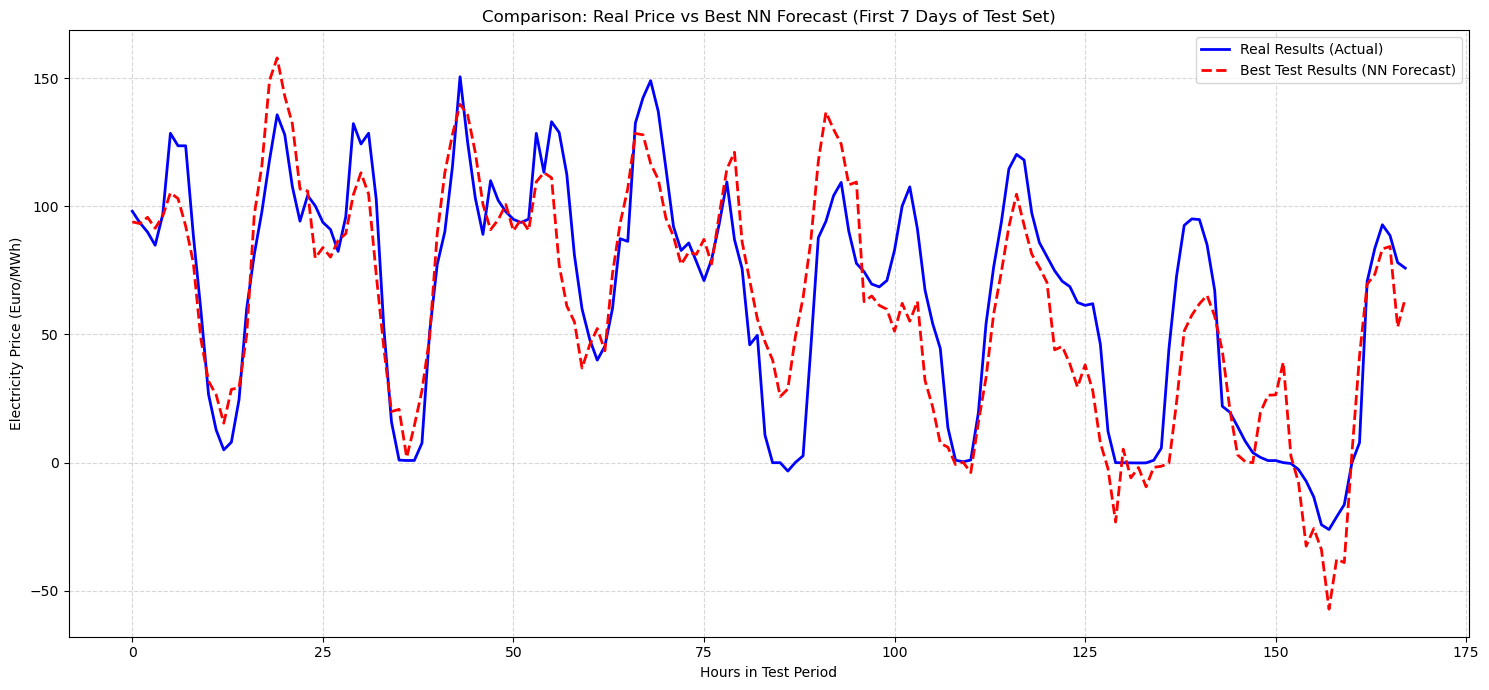

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Load Data
df_all = pd.read_csv('Full_Dataset.csv', header=0)
df_all.rename(columns={'Date': 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

# 2. Preprocess: Handle Duplicates & Outliers & Resample
df_all = df_all.groupby(level=0).mean() # Handle DST duplicates
# Simple outlier capping for Price_BE
mean_p = df_all.Price_BE.mean()
std_p = df_all.Price_BE.std()
df_all.loc[df_all.Price_BE >= mean_p + 5*std_p, 'Price_BE'] = mean_p + 5*std_p
df_all.loc[df_all.Price_BE <= mean_p - 5*std_p, 'Price_BE'] = mean_p + 5*std_p

data = df_all[['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']].resample('1h').mean().ffill()
data.columns = ['belpex', 'solar', 'wind', 'load']

# 3. Feature Engineering
price = data.belpex.values
solar = data.solar.values
wind = data.wind.values
load = data.load.values

n_hours = 24
X_list, Y_list = [], []
days = len(data) // n_hours
for d in range(7, days):
    y_day = price[d*24 : (d+1)*24]
    price_lag1 = price[(d-1)*24 : d*24]
    price_lag7 = price[(d-7)*24 : (d-6)*24]
    solar_curr = solar[d*24 : (d+1)*24]
    wind_curr = wind[d*24 : (d+1)*24]
    load_curr = load[d*24 : (d+1)*24]
    X_list.append(np.concatenate([price_lag1, price_lag7, solar_curr, wind_curr, load_curr]))
    Y_list.append(y_day)

X, Y = np.array(X_list), np.array(Y_list)

# 4. Scale and Split
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X)
Y_scaled = scaler_y.fit_transform(Y)

X_train_val, X_test, Y_train_val, Y_test = train_test_split(X_scaled, Y_scaled, test_size=0.15, shuffle=False)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.176, shuffle=False)

# 5. Build "Best" Model (2 layers, 96 nodes, tanh)
model = Sequential([
    Dense(96, input_dim=X_train.shape[1], activation='tanh'),
    Dense(96, activation='tanh'),
    Dense(24, activation='linear')
])
model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
model.fit(X_train, Y_train, epochs=100, batch_size=32, validation_data=(X_val, Y_val), verbose=0)

# 6. Predict and Invert Scaling
predictions_scaled = model.predict(X_test)
predictions = scaler_y.inverse_transform(predictions_scaled)
actuals = scaler_y.inverse_transform(Y_test)

# 7. Plot results
# We'll plot the first 7 days of the test set for clarity
plt.figure(figsize=(15, 7))
num_days_to_plot = 7
plt.plot(actuals[:num_days_to_plot].flatten(), label='Real Results (Actual)', color='blue', linewidth=2)
plt.plot(predictions[:num_days_to_plot].flatten(), label='Best Test Results (NN Forecast)', color='red', linestyle='--', linewidth=2)
plt.title(f'Comparison: Real Price vs Best NN Forecast (First {num_days_to_plot} Days of Test Set)')
plt.xlabel('Hours in Test Period')
plt.ylabel('Electricity Price (Euro/MWh)')
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('best_test_comparison.png')

print("Plot saved as best_test_comparison.png")

Starting Grid Search...
Evaluating: Layers=1, Nodes=64, Activation=relu...


c:\Users\sarah\anaconda3\envs\smart_grid_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Evaluating: Layers=1, Nodes=64, Activation=tanh...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Evaluating: Layers=1, Nodes=64, Activation=sigmoid...
Evaluating: Layers=1, Nodes=64, Activation=linear...
Evaluating: Layers=1, Nodes=128, Activation=relu...
Evaluating: Layers=1, Nodes=128, Activation=tanh...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Evaluating: Layers=1, Nodes=128, Activation=sigmoid...
Evaluating: Layers=1, Nodes=128, Activation=linear...
Evaluating: Layers=2, Nodes=64, Activation=relu...
Evaluating: Layers=2, Nodes=64, Activation=tanh...
Evaluating: Layers=2, Nodes=64, Activation=sigmoid...
Evaluating: Layers=2, Nodes=64, Activation=linear...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Evaluating: Layers=2, Nodes=128, Activation=relu...
Evaluating: Layers=2, Nodes=128, Activation=tanh...
Evaluating: Layers=2, Nodes=128, Activation=sigmoid...
Evaluating: Layers=2, Nodes=128, Activation=linear...

--- Model Comparison Table ---
 Layers  Nodes Activati

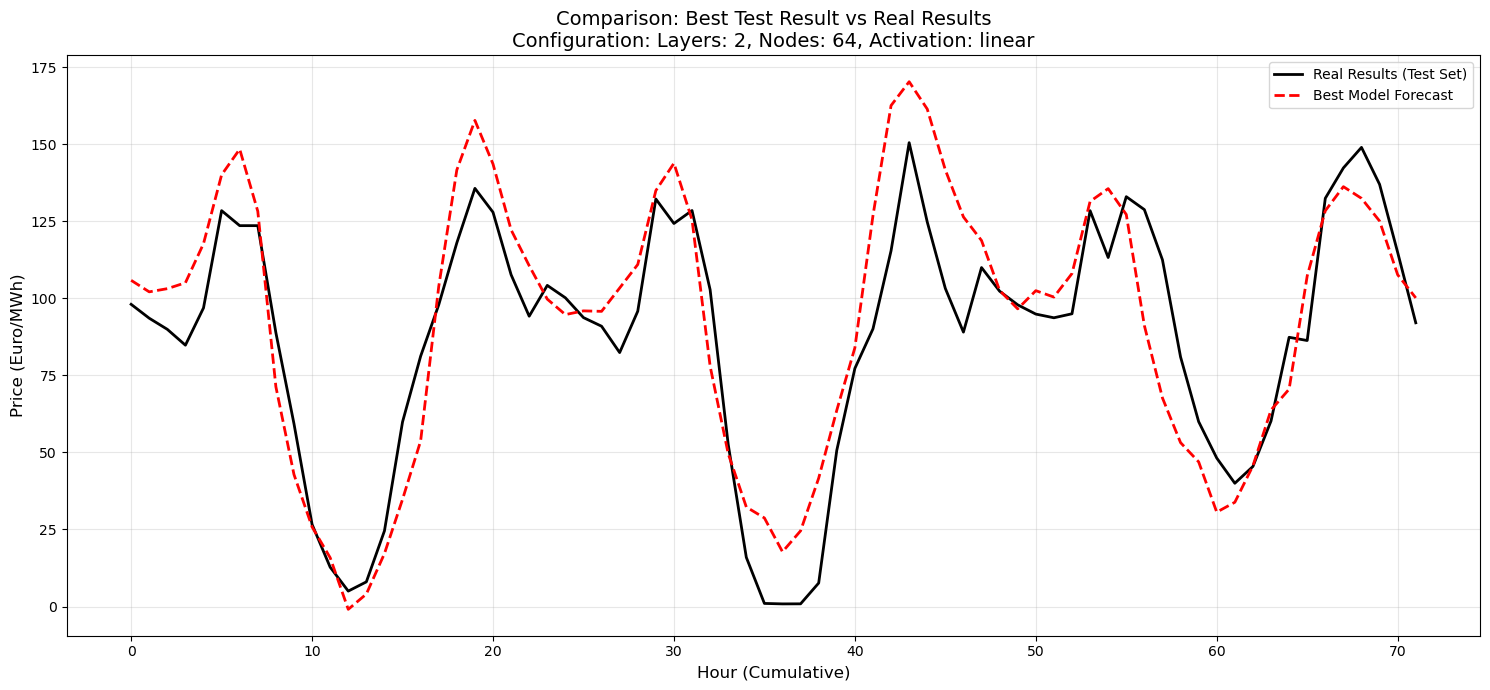

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# ==========================================
# 1. DATA PREPARATION
# ==========================================
df_all = pd.read_csv('Full_Dataset.csv', header=0)
df_all.rename(columns={'Date': 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

df_all = df_all.groupby(level=0).mean()
data = df_all[['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']].resample('1h').mean().ffill()
data.columns = ['belpex', 'solar', 'wind', 'load']

price, solar, wind, load = data.belpex.values, data.solar.values, data.wind.values, data.load.values
n_hours = 24
X_list, Y_list = [], []
days = len(data) // n_hours

for d in range(7, days):
    y_day = price[d*24 : (d+1)*24]
    features = np.concatenate([
        price[(d-1)*24 : d*24], 
        price[(d-7)*24 : (d-6)*24], 
        solar[d*24 : (d+1)*24], 
        wind[d*24 : (d+1)*24], 
        load[d*24 : (d+1)*24]
    ])
    X_list.append(features)
    Y_list.append(y_day)

X, Y = np.array(X_list), np.array(Y_list)

# Scaling
scaler_x, scaler_y = StandardScaler(), StandardScaler()
X_scaled = scaler_x.fit_transform(X)
Y_scaled = scaler_y.fit_transform(Y)

# CORRECTED SPLITTING LOGIC
# First split: Separate the test set (15%)
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X_scaled, Y_scaled, test_size=0.15, shuffle=False)
# Second split: Separate training (70%) and validation (15%)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.176, shuffle=False)

# ==========================================
# 2. GRID SEARCH
# ==========================================
layer_options = [1, 2]
node_options = [64, 128]
activation_options = ['relu', 'tanh', 'sigmoid', 'linear'] # Linear, Non-linear, and Sigmoid

results_list = []
best_test_mse = float('inf')
best_predictions = None
best_config = ""

print("Starting Grid Search...")
for layers in layer_options:
    for nodes in node_options:
        for act in activation_options:
            print(f"Evaluating: Layers={layers}, Nodes={nodes}, Activation={act}...")
            
            model = Sequential()
            model.add(Dense(nodes, input_dim=X_train.shape[1], activation=act))
            for _ in range(layers - 1):
                model.add(Dense(nodes, activation=act))
            model.add(Dense(24, activation='linear')) # Output layer for prices
            
            model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
            model.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=0)
            
            # Record MSEs
            train_mse = model.evaluate(X_train, Y_train, verbose=0)
            val_mse = model.evaluate(X_val, Y_val, verbose=0)
            test_mse = model.evaluate(X_test, Y_test, verbose=0)
            
            results_list.append({
                'Layers': layers, 'Nodes': nodes, 'Activation': act,
                'Train_MSE': round(train_mse, 5), 
                'Val_MSE': round(val_mse, 5), 
                'Test_MSE': round(test_mse, 5)
            })
            
            if test_mse < best_test_mse:
                best_test_mse = test_mse
                best_predictions = model.predict(X_test)
                best_config = f"Layers: {layers}, Nodes: {nodes}, Activation: {act}"

# ==========================================
# 3. RESULTS TABLE & PLOT
# ==========================================
comparison_df = pd.DataFrame(results_list).sort_values(by='Test_MSE')
print("\n--- Model Comparison Table ---")
print(comparison_df.to_string(index=False))

# Prepare data for plotting
final_preds = scaler_y.inverse_transform(best_predictions)
final_actuals = scaler_y.inverse_transform(Y_test)

plt.figure(figsize=(15, 7))
plt.plot(final_actuals[:3].flatten(), label='Real Results (Test Set)', color='black', linewidth=2)
plt.plot(final_preds[:3].flatten(), label='Best Model Forecast', color='red', linestyle='--', linewidth=2)

plt.title(f'Comparison: Best Test Result vs Real Results\nConfiguration: {best_config}', fontsize=14)
plt.xlabel('Hour (Cumulative)', fontsize=12)
plt.ylabel('Price (Euro/MWh)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()